In [3]:
# CLIP model for fMRI IMages mapping
## using simple Ridge regression
# worked on algonauts dataset but not on things dataset

In [4]:
import os
import argparse
import math
import torch
import torchvision
# from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import ToTensor, Compose, Normalize
from tqdm import tqdm
import random
import numpy as np
import timm
import numpy as np
from PIL import Image
import pandas as pd

from einops import repeat, rearrange
from einops.layers.torch import Rearrange
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from timm.models.layers import trunc_normal_
from timm.models.vision_transformer import Block
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from lightly.loss import BarlowTwinsLoss
from lightly.loss import NTXentLoss
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from pycocotools.coco import COCO

from matplotlib import pyplot as plt
%matplotlib inline

# import wandb

In [5]:
def setup_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed()

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Things dataset

In [7]:
# # load image features
# print('IMAGES -------')
# loaded = torch.load('../resources/clip_img_feat_224')
# train_feat_img = loaded['train_feat']
# test_feat_img = loaded['test_feat']
# train_feat_img = train_feat_img.squeeze(1)
# test_feat_img = test_feat_img.squeeze(1)
# train_feat_img = train_feat_img.detach().cpu().numpy()
# test_feat_img = test_feat_img.detach().cpu().numpy()
# print(train_feat_img.shape, test_feat_img.shape)
# print(np.max(train_feat_img), np.min(train_feat_img))
# scaler1 = MinMaxScaler()
# train_feat_img = scaler1.fit_transform(train_feat_img)
# test_feat_img = scaler1.transform(test_feat_img)
# print(np.max(train_feat_img), np.min(train_feat_img))
# train_feat_img = train_feat_img.astype('float32')
# test_feat_img = test_feat_img.astype('float32')

# # # load text features
# # print('TEXT -------')
# # loaded = torch.load('../resources/clip_txt_feat_224')
# # train_feat_img = loaded['train_feat']
# # test_feat_img = loaded['test_feat']
# # train_feat_img = train_feat_img.squeeze(1)
# # test_feat_img = test_feat_img.squeeze(1)
# # train_feat_img = train_feat_img.detach().cpu().numpy()
# # test_feat_img = test_feat_img.detach().cpu().numpy()
# # print(train_feat_img.shape, test_feat_img.shape)
# # print(np.max(train_feat_img), np.min(train_feat_img))
# # scaler1 = MinMaxScaler()
# # train_feat_img = scaler1.fit_transform(train_feat_img)
# # test_feat_img = scaler1.transform(test_feat_img)
# # print(np.max(train_feat_img), np.min(train_feat_img))
# # train_feat_img = train_feat_img.astype('float32')
# # test_feat_img = test_feat_img.astype('float32')


# # FMRI
# print('FMRI ----------')
# train_file = np.load('../resources/sub2-fmri-train.npy')
# test_file = np.load('../resources/sub2-fmri-test.npy')
# train_file = train_file.T
# test_file = test_file.T
# print(train_file.shape, test_file.shape)
# print(np.max(train_file), np.min(train_file))
# scaler2 = MinMaxScaler()
# train_file = scaler2.fit_transform(train_file)
# test_file = scaler2.transform(test_file)
# print(np.max(train_file), np.min(train_file))
# train_feat_fmri = train_file.astype('float32')
# test_feat_fmri = test_file.astype('float32')

# # # FMRI embeddings
# # train_file = np.load('../resources/ae_train_fmri_embed.npy')
# # test_file = np.load('../resources/ae_test_fmri_embed.npy')
# # print(train_file.shape, test_file.shape)
# # print(np.max(train_file), np.min(train_file))
# # train_file = train_file.astype('float32')
# # test_file = test_file.astype('float32')

### Algonauts NSD dataset

In [ ]:
data_dir = '/home/Documents/research/projects/algonauts_2023/resources/algonauts_2023_challenge_data/'
data_dir = os.path.join(data_dir, 'subj01')

Cefi


In [9]:
# # load image features
# loaded = torch.load(data_dir+'/clip_nsd_img_feat_224')
# feat_img = loaded['train_feat']
# feat_img = feat_img.squeeze(1)
# feat_img = feat_img.detach().cpu().numpy()
# print(feat_img.shape)

In [10]:
# # train test split because given test set does not have fMRI
# train_feat_img = feat_img[:7000]
# test_feat_img = feat_img[7000:]
# print(train_feat_img.shape, test_feat_img.shape)

In [11]:
# # normalize
# print(np.max(train_feat_img), np.min(test_feat_img))
# scaler1 = MinMaxScaler()
# train_feat_img = scaler1.fit_transform(train_feat_img)
# test_feat_img = scaler1.transform(test_feat_img)
# print(np.max(train_feat_img), np.min(train_feat_img))
# train_feat_img = train_feat_img.astype('float32')
# test_feat_img = test_feat_img.astype('float32')

In [ ]:
nsd_captions = pd.read_csv("/home/Documents/research/projects/algonauts_2023/resources/nsd_captions.csv")
nsd_captions.shape

(49205, 6)

In [13]:
nsd_captions.head()

,image_id,nsd_id,coco_id,coco_caption_id,coco_caption,split
0,train-0001_nsd-00013.png,13,24610,162385,A disorderly living area is free from decorati...,Test
1,train-0001_nsd-00013.png,13,24610,168364,"A small living space with a couch, desk, chair...",Test
2,train-0001_nsd-00013.png,13,24610,170512,There is a laptop computer in a room with a co...,Test
3,train-0001_nsd-00013.png,13,24610,175837,A simple room with minimal decor and furniture.,Test
4,train-0001_nsd-00013.png,13,24610,178792,A small room with a computer and bookcase.,Test


In [14]:
def extract_nth_rows(dataframe, n):
    # Extract every nth row
    return dataframe.iloc[n-1::n]

nsd_captions_subset = extract_nth_rows(nsd_captions, 5)
nsd_captions_subset.shape

(9841, 6)

In [15]:
captions_list = nsd_captions_subset.coco_caption.tolist()
train_captions = captions_list[:7000]
test_captions = captions_list[7000:]

In [16]:
# load text feat
text_feat = np.load(data_dir+'/clip_nsd_caption_feat.npy')
text_feat = text_feat.squeeze(1)
text_feat.shape

(9841, 512)

In [17]:
# train test split because given test set does not have fMRI
train_feat_txt = text_feat[:7000]
test_feat_txt = text_feat[7000:]
print(train_feat_txt.shape, test_feat_txt.shape)

(7000, 512) (2841, 512)


In [18]:
# normalize
print(np.max(train_feat_txt), np.min(test_feat_txt))
scaler2 = MinMaxScaler()
train_feat_txt = scaler2.fit_transform(train_feat_txt)
test_feat_txt = scaler2.transform(test_feat_txt)
print(np.max(train_feat_txt), np.min(test_feat_txt))
train_feat_txt = train_feat_txt.astype('float32')
test_feat_txt = test_feat_txt.astype('float32')
# train_feat_txt, test_feat_txt

8.483438 -3.940516
1.0000001 -0.1722239


In [19]:
# load fMRI training data
fmri_dir = os.path.join(data_dir, 'training_split', 'training_fmri')
lh_fmri = np.load(os.path.join(fmri_dir, 'lh_training_fmri.npy'))
rh_fmri = np.load(os.path.join(fmri_dir, 'rh_training_fmri.npy'))

print('LH training fMRI data shape:')
print(lh_fmri.shape)
print('(Training stimulus images × LH vertices)')

print('\nRH training fMRI data shape:')
print(rh_fmri.shape)
print('(Training stimulus images × RH vertices)')

LH training fMRI data shape:
(9841, 19004)
(Training stimulus images × LH vertices)

RH training fMRI data shape:
(9841, 20544)
(Training stimulus images × RH vertices)


In [20]:
train_feat_fmri_lh = lh_fmri[:7000]
test_feat_fmri_lh = lh_fmri[7000:]
train_feat_fmri_rh = rh_fmri[:7000]
test_feat_fmri_rh = rh_fmri[7000:]
print(train_feat_fmri_lh.shape, test_feat_fmri_lh.shape)

(7000, 19004) (2841, 19004)


In [21]:
# normalize
print(np.max(train_feat_fmri_lh), np.min(train_feat_fmri_lh))
scaler3 = MinMaxScaler()
train_feat_fmri_lh = scaler3.fit_transform(train_feat_fmri_lh)
test_feat_fmri_lh = scaler3.transform(test_feat_fmri_lh)
print(np.max(train_feat_fmri_lh), np.min(train_feat_fmri_lh))
train_feat_fmri_lh = train_feat_fmri_lh.astype('float32')
test_feat_fmri_lh = test_feat_fmri_lh.astype('float32')

6.2208066 -5.5488534
1.0000001 0.0


In [22]:
print(np.max(train_feat_fmri_rh), np.min(train_feat_fmri_rh))
scaler4 = MinMaxScaler()
train_feat_fmri_rh = scaler4.fit_transform(train_feat_fmri_rh)
test_feat_fmri_rh = scaler4.transform(test_feat_fmri_rh)
print(np.max(train_feat_fmri_rh), np.min(train_feat_fmri_rh))
train_feat_fmri_rh = train_feat_fmri_rh.astype('float32')
test_feat_fmri_rh = test_feat_fmri_rh.astype('float32')

6.2803955 -6.224722
1.0000001 0.0


#### Model on text features

In [23]:
# train_feat_txt, test_feat_txt

In [29]:
%%time

clf_lh = Ridge(alpha=100)
# clf = ExtraTreesRegressor(n_estimators=500)
clf_lh.fit(train_feat_fmri_lh, train_feat_txt)
train_feat_img_pred_lh = clf_lh.predict(train_feat_fmri_lh)
test_feat_img_pred_lh = clf_lh.predict(test_feat_fmri_lh)
print(train_feat_img_pred_lh.shape, test_feat_img_pred_lh.shape)

(7000, 512) (2841, 512)
CPU times: user 26.4 s, sys: 2.26 s, total: 28.7 s
Wall time: 8.53 s


In [30]:
%%time

clf_rh = Ridge(alpha=100)
# clf = ExtraTreesRegressor(n_estimators=500)
clf_rh.fit(train_feat_fmri_rh, train_feat_txt)
train_feat_img_pred_rh = clf_rh.predict(train_feat_fmri_rh)
test_feat_img_pred_rh = clf_rh.predict(test_feat_fmri_rh)
print(train_feat_img_pred_rh.shape, test_feat_img_pred_rh.shape)

(7000, 512) (2841, 512)
CPU times: user 28.2 s, sys: 2.33 s, total: 30.5 s
Wall time: 9.07 s


In [31]:
train_feat_img_pred = np.mean([train_feat_img_pred_lh, train_feat_img_pred_rh],axis=0)
test_feat_img_pred = np.mean([test_feat_img_pred_lh, test_feat_img_pred_rh],axis=0)
print(train_feat_img_pred.shape, test_feat_img_pred.shape)

(7000, 512) (2841, 512)


In [32]:
# # normalize predictions
# test_feat_img_pred = scaler2.transform(test_feat_img_pred)      # didnt work
# print(np.max(test_feat_img_pred), np.min(test_feat_img_pred))
# test_feat_img_pred = test_feat_img_pred.astype('float32')
# print(np.max(test_feat_img_pred), np.min(test_feat_img_pred))

In [33]:
print(mean_squared_error(test_feat_txt, test_feat_img_pred))
print(mean_squared_error(train_feat_txt, train_feat_img_pred))

0.016338972
0.0082784835


In [35]:
clf_rh_weights = np.mean(clf_rh.coef_, axis=0)
clf_rh_weights.shape

(20544,)

In [36]:
clf_lh_weights = np.mean(clf_lh.coef_, axis=0)
clf_lh_weights.shape

(19004,)

### testing

In [37]:
test_num = 6

In [38]:
sample_test_img_embed = test_feat_img_pred[test_num]
sample_test_img_embed = sample_test_img_embed.reshape(1, -1)
sample_test_img_embed.shape

(1, 512)

In [39]:
similarities = cosine_similarity(sample_test_img_embed, train_feat_txt)
similarities.shape

(1, 7000)

In [40]:
pred_inx = 0
indices = np.argsort(similarities.flatten())[-1:]
print("predicted labels:")
for idx in indices:
    print(idx)
    pred_inx = idx
pred_inx

predicted labels:
4306


4306

In [41]:
print('Actual - ', test_captions[test_num])
print('predicted - ', train_captions[pred_inx])

Actual -  A man that is sitting down holding bread.
predicted -  A man is sitting with another and holding a plate of food.


In [60]:
print("processing images...")
img_dir  = os.path.join(data_dir, 'training_split', 'training_images')
print(img_dir)
img_list = os.listdir(img_dir)
img_list.sort()
train_img_list = img_list[:7000]
test_img_list = img_list[7000:]

processing images...
/home/vijay/Documents/research/projects/algonauts_2023/resources/algonauts_2023_challenge_data/subj01/training_split/training_images


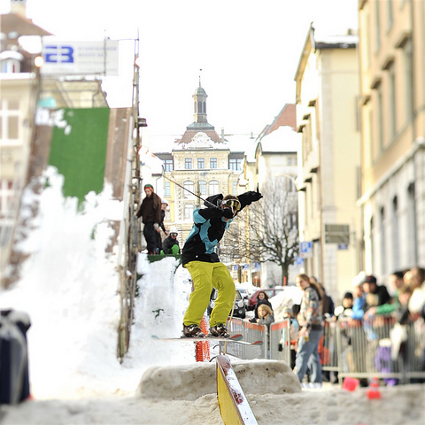

In [61]:
#actual
img_path = img_dir + "/" + test_img_list[test_num]
img = Image.open(img_path)
img

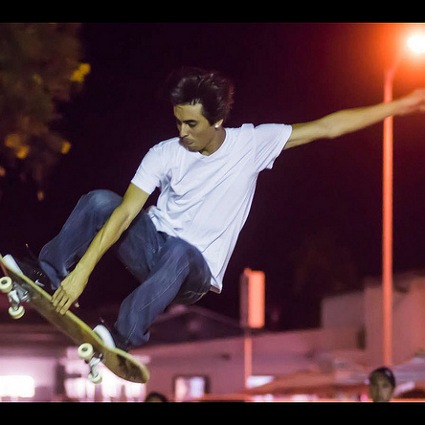

In [62]:
#prediction
img_path = img_dir + "/" + test_img_list[pred_inx]
img = Image.open(img_path)
img

### weight compression by RoI

In [42]:
# Load the ROI classes mapping dictionaries
roi_mapping_files = ['mapping_prf-visualrois.npy', 'mapping_floc-bodies.npy',
    'mapping_floc-faces.npy', 'mapping_floc-places.npy',
    'mapping_floc-words.npy', 'mapping_streams.npy']
roi_name_maps = []
for r in roi_mapping_files:
    roi_name_maps.append(np.load(os.path.join(data_dir, 'roi_masks', r),
        allow_pickle=True).item())

In [43]:
# Load the ROI brain surface maps
lh_challenge_roi_files = ['lh.prf-visualrois_challenge_space.npy',
    'lh.floc-bodies_challenge_space.npy', 'lh.floc-faces_challenge_space.npy',
    'lh.floc-places_challenge_space.npy', 'lh.floc-words_challenge_space.npy',
    'lh.streams_challenge_space.npy']
rh_challenge_roi_files = ['rh.prf-visualrois_challenge_space.npy',
    'rh.floc-bodies_challenge_space.npy', 'rh.floc-faces_challenge_space.npy',
    'rh.floc-places_challenge_space.npy', 'rh.floc-words_challenge_space.npy',
    'rh.streams_challenge_space.npy']
lh_challenge_rois = []
rh_challenge_rois = []
for r in range(len(lh_challenge_roi_files)):
    lh_challenge_rois.append(np.load(os.path.join(data_dir, 'roi_masks',
        lh_challenge_roi_files[r])))
    rh_challenge_rois.append(np.load(os.path.join(data_dir, 'roi_masks',
        rh_challenge_roi_files[r])))

In [44]:
print(lh_challenge_rois[0].shape, rh_challenge_rois[0].shape, len(lh_challenge_roi_files))

(19004,) (20544,) 6


In [45]:
# 
roi_names = []
lh_idxes = []
rh_idxes = []
for r1 in range(len(lh_challenge_rois)):
    for r2 in roi_name_maps[r1].items():
        if r2[0] != 0: # zeros indicate to vertices falling outside the ROI of interest
            roi_names.append(r2[1])
            lh_roi_idx = np.where(lh_challenge_rois[r1] == r2[0])[0]
            rh_roi_idx = np.where(rh_challenge_rois[r1] == r2[0])[0]
            lh_idxes.append(lh_roi_idx)
            rh_idxes.append(rh_roi_idx)
            print(r2[1], lh_roi_idx.shape, rh_roi_idx.shape)
# roi_names.append('All vertices')

V1v (710,) (444,)
V1d (828,) (991,)
V2v (632,) (887,)
V2d (692,) (725,)
V3v (567,) (682,)
V3d (669,) (535,)
hV4 (531,) (765,)
EBA (2837,) (3400,)
FBA-1 (574,) (206,)
FBA-2 (0,) (856,)
mTL-bodies (0,) (0,)
OFA (432,) (305,)
FFA-1 (552,) (330,)
FFA-2 (0,) (629,)
mTL-faces (0,) (0,)
aTL-faces (0,) (0,)
OPA (1863,) (2806,)
PPA (1311,) (891,)
RSC (401,) (660,)
OWFA (317,) (590,)
VWFA-1 (1381,) (397,)
VWFA-2 (461,) (431,)
mfs-words (490,) (0,)
mTL-words (0,) (0,)
early (5169,) (5304,)
midventral (867,) (1050,)
midlateral (1091,) (1191,)
midparietal (853,) (1133,)
ventral (4974,) (4852,)
lateral (3129,) (3578,)
parietal (2346,) (2314,)


In [46]:
#
df_rh = pd.DataFrame(columns=roi_names)
df_lh = pd.DataFrame(columns=roi_names)
df_mean = pd.DataFrame(columns=roi_names)

rh_coeff = clf_rh_weights
lh_coeff = clf_lh_weights
rh_weight_lst = []
lh_weight_lst = []
weight_lst = []
# region loop:
for j in range(31):
    print("Region - ",roi_names[j])
    rh_indexes = rh_idxes[j]
    lh_indexes = lh_idxes[j]
    rh_weights = rh_coeff[rh_indexes]
    lh_weights = lh_coeff[lh_indexes]
    rh_weights_mn = np.mean(rh_weights)
    lh_weights_mn = np.mean(lh_weights)
    rh_weight_lst.append(rh_weights_mn)
    lh_weight_lst.append(lh_weights_mn)
    weight_lst.append(np.mean([rh_weights_mn,lh_weights_mn]))
    print(rh_indexes.shape, lh_indexes.shape, rh_weights_mn, lh_weights_mn)
print("\n")
df_rh.loc[0] = rh_weight_lst
df_lh.loc[0] = lh_weight_lst
df_mean.loc[0] = weight_lst

Region -  V1v
(444,) (710,) -1.6150072e-06 6.2569734e-06
Region -  V1d
(991,) (828,) -4.0046953e-07 -1.8215159e-06
Region -  V2v
(887,) (632,) 5.0986523e-06 -4.8967496e-07
Region -  V2d
(725,) (692,) 1.2977786e-05 4.1498356e-06
Region -  V3v
(682,) (567,) -2.5614293e-06 -9.501653e-06
Region -  V3d
(535,) (669,) -1.7964865e-05 -8.6957125e-06
Region -  hV4
(765,) (531,) -2.8740487e-06 -1.1215312e-06
Region -  EBA
(3400,) (2837,) 1.670541e-06 3.4214822e-06
Region -  FBA-1
(206,) (574,) 1.1790555e-05 -2.7083497e-06
Region -  FBA-2
(856,) (0,) -9.630825e-06 nan
Region -  mTL-bodies
(0,) (0,) nan nan
Region -  OFA
(305,) (432,) -1.0599159e-06 -6.288826e-06
Region -  FFA-1
(330,) (552,) -1.9271201e-05 1.4421092e-05
Region -  FFA-2
(629,) (0,) 3.972047e-06 nan
Region -  mTL-faces
(0,) (0,) nan nan
Region -  aTL-faces
(0,) (0,) nan nan
Region -  OPA
(2806,) (1863,) 3.6142212e-06 2.7468973e-06
Region -  PPA
(891,) (1311,) 7.811748e-07 -2.9873083e-06
Region -  RSC
(660,) (401,) 7.666874e-06 1.077

/home/vijay/anaconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/vijay/anaconda3/envs/pytorch/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [48]:
print(df_rh.shape,df_lh.shape, df_mean.shape)

(1, 31) (1, 31) (1, 31)


In [151]:
len(rh_weight_lst)
float_coefficients = np.array([float(x) if x == x else np.nan for x in rh_weight_lst])
len(float_coefficients)
# Get non-NaN coefficients and their indices
valid_mask = ~np.isnan(float_coefficients)
valid_coefficients = float_coefficients[valid_mask]
valid_indices = np.where(valid_mask)[0]
valid_coefficients.shape

n_remove = int(len(valid_coefficients) * 1)
n_remove

26

In [49]:
def process_coefficients(coef_array, remove_percent=0.2):
    
    # Convert to float array, handling NaN values properly
    float_coefficients = np.array([float(x) if x == x else np.nan for x in coef_array])
    
    # Get non-NaN coefficients and their indices
    valid_mask = ~np.isnan(float_coefficients)
    valid_coefficients = float_coefficients[valid_mask]
    valid_indices = np.where(valid_mask)[0]
    
    # Calculate number of coefficients to remove
    n_remove = int(len(valid_coefficients) * remove_percent)
    
    # Sort by absolute values
    abs_values = np.abs(valid_coefficients)
    sorted_indices = np.argsort(abs_values)
    
    # Get indices to remove and keep
    remove_indices = sorted_indices[:n_remove]
    keep_indices = sorted_indices[n_remove:]
    
    # Print analysis
    print("Initial Analysis:")
    print(f"Total coefficients: {len(float_coefficients)}")
    print(f"Non-NaN coefficients: {len(valid_coefficients)}")
    print(f"NaN values: {np.sum(np.isnan(float_coefficients))}")
    print(f"Removing {n_remove} coefficients ({remove_percent*100}%)")
    
    # Create final array
    final_coefficients = np.full_like(float_coefficients, np.nan)
    final_coefficients[valid_indices[keep_indices]] = valid_coefficients[keep_indices]
    
    # Calculate threshold
    threshold = abs_values[sorted_indices[n_remove]]
    print(f"Threshold value (minimum absolute value to keep): {threshold:e}")
    
    # Calculate retained weight
    original_weight = np.sum(abs_values)
    final_weight = np.sum(abs_values[keep_indices])
    weight_retained = (final_weight / original_weight) * 100
    
    print(f"Total absolute weight retained: {weight_retained:.2f}%")
    
    return final_coefficients, valid_indices[keep_indices], valid_indices[remove_indices]

In [218]:
# Process the coefficients
final_coef_rh, kept_indices_rh, remove_indices_rh = process_coefficients(rh_weight_lst, .2)

Initial Analysis:
Total coefficients: 31
Non-NaN coefficients: 26
NaN values: 5
Removing 5 coefficients (20.0%)
Threshold value (minimum absolute value to keep): 8.736923e-07
Total absolute weight retained: 97.70%


In [219]:
# Process the coefficients
final_coef_lh, kept_indices_lh, remove_indices_lh = process_coefficients(lh_weight_lst, .2)

Initial Analysis:
Total coefficients: 31
Non-NaN coefficients: 25
NaN values: 6
Removing 5 coefficients (20.0%)
Threshold value (minimum absolute value to keep): 1.592038e-06
Total absolute weight retained: 96.17%


In [220]:
kept_indices_lh

array([30,  1, 28, 22, 26, 27,  8, 16, 17, 20,  7,  3,  0, 11, 25,  5,  4,
       18, 12, 19])

In [221]:
remove_indices_lh

array([29,  2,  6, 21, 24])

In [222]:
clf_lh_weights_v2 = clf_lh.coef_.copy()
for i in range(len(lh_idxes)):
    if i in remove_indices_lh:
        region_indices = lh_idxes[i]
        print(region_indices.shape)      
        clf_lh_weights_v2[:, region_indices] = 0

(632,)
(531,)
(461,)
(5169,)
(3129,)


In [223]:
clf_rh_weights_v2 = clf_rh.coef_.copy()
for i in range(len(rh_idxes)):
    if i in remove_indices_rh:
        region_indices = rh_idxes[i]
        print(region_indices.shape)
        clf_rh_weights_v2[:, region_indices] = 0

(991,)
(891,)
(431,)
(1133,)
(2314,)


In [224]:
clf_rh_weights_v2[clf_rh_weights_v2 == 0].shape

(2949120,)

In [225]:
import copy

clf_rh_v2 = copy.deepcopy(clf_rh)
clf_lh_v2 = copy.deepcopy(clf_lh)

clf_rh_v2.coef_ = np.array(clf_rh_weights_v2)
clf_lh_v2.coef_ = np.array(clf_lh_weights_v2)

In [226]:
test_feat_img_pred_lh = clf_lh_v2.predict(test_feat_fmri_lh)
test_feat_img_pred_rh = clf_rh_v2.predict(test_feat_fmri_rh)
test_feat_img_pred = np.mean([test_feat_img_pred_lh, test_feat_img_pred_rh],axis=0)

In [227]:
sample_test_img_embed = test_feat_img_pred[test_num]
sample_test_img_embed = sample_test_img_embed.reshape(1, -1)
similarities = cosine_similarity(sample_test_img_embed, train_feat_txt)
pred_inx = 0
indices = np.argsort(similarities.flatten())[-1:]
print("predicted labels:")
for idx in indices:
    print(idx)
    pred_inx = idx
print('Actual - ', test_captions[test_num])
print('predicted - ', train_captions[pred_inx])

predicted labels:
3562
Actual -  A man that is sitting down holding bread.
predicted -  a man in the middle of a beach holding a line
